# 01 -- Data Validation
Coverage heatmap, return sanity, universe completeness.

In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
os.makedirs('../reports', exist_ok=True)

art = pd.read_parquet('../data/processed/panel_artemis_daily.parquet')
mkt = pd.read_parquet('../data/processed/panel_market_daily.parquet')
uni = pd.read_parquet('../data/processed/universe_monthly.parquet')

for df in [art, mkt, uni]:
    df['date'] = pd.to_datetime(df['date'])

art = art.sort_values(['symbol', 'date']).reset_index(drop=True)
mkt = mkt.sort_values(['symbol', 'date']).reset_index(drop=True)
uni = uni.sort_values(['date', 'symbol']).reset_index(drop=True)

print(f"Artemis daily : {art.shape}  |  {art['date'].min().date()} -> {art['date'].max().date()}")
print(f"Market daily  : {mkt.shape}  |  {mkt['date'].min().date()} -> {mkt['date'].max().date()}")
print(f"Universe      : {uni.shape}  |  {uni['date'].nunique()} rebalance dates, {uni['symbol'].nunique()} unique symbols")
print()
print("Artemis null rates:")
print(art.isnull().mean().drop('date').round(3).to_string())


Artemis daily : (160487, 9)  |  2021-01-01 -> 2024-12-31
Market daily  : (145020, 4)  |  2021-01-01 -> 2024-12-31
Universe      : (2400, 4)  |  48 rebalance dates, 95 unique symbols

Artemis null rates:
symbol     0.000
dau        0.484
fees       0.622
mc         0.097
price      0.096
revenue    0.585
tvl        0.884
txns       0.666


In [2]:
## Section 1: Universe Coverage
rebalance_dates = sorted(uni['date'].unique())
cov_rows = []
for t in rebalance_dates:
    syms = uni[uni['date'] == t]['symbol'].tolist()
    art_t = art[(art['date'] == t) & art['symbol'].isin(syms)]
    n_price = art_t['price'].notna().sum()
    cov_rows.append({'date': t, 'n_universe': len(syms), 'n_with_price': n_price})

ucov = pd.DataFrame(cov_rows)
n_complete = (ucov['n_with_price'] >= 40).sum()
print(f"Months with >=40 coins having Artemis price: {n_complete} / {len(ucov)}")
print(ucov[['n_universe', 'n_with_price']].describe().round(1))


Months with >=40 coins having Artemis price: 48 / 48
       n_universe  n_with_price
count        48.0          48.0
mean         50.0          50.0
std           0.0           0.0
min          50.0          50.0
25%          50.0          50.0
50%          50.0          50.0
75%          50.0          50.0
max          50.0          50.0


Coverage (non-null days in trailing 30d window) -- % of (symbol,month) pairs with >15 obs:
  fees        :  47.6%
  dau         :  57.3%
  tvl         :   9.1%
  txns        :  45.4%
  revenue     :  55.3%


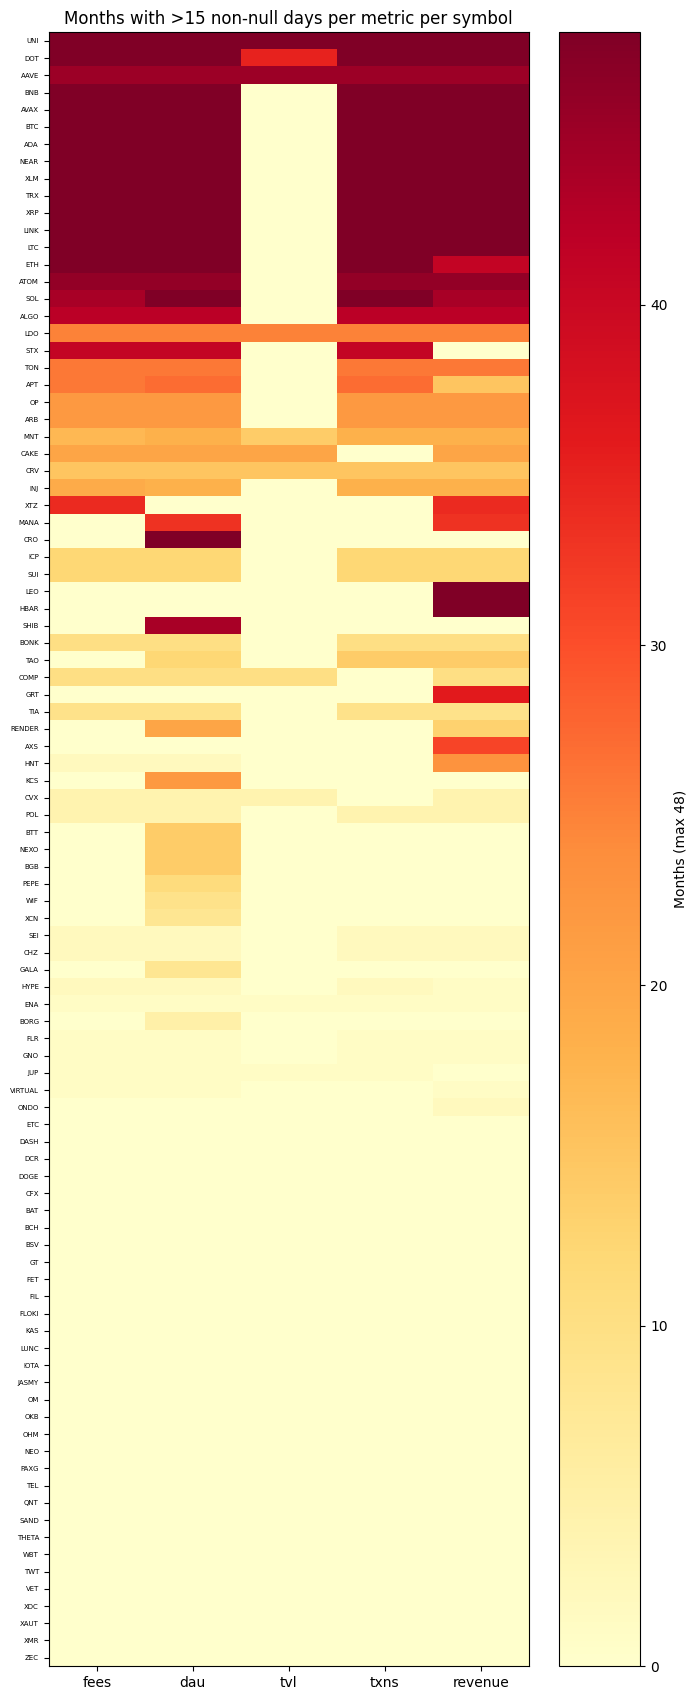

Coverage heatmap saved to reports/coverage_heatmap.png


In [3]:
## Section 2: Artemis Coverage Heatmap
metrics = ['fees', 'dau', 'tvl', 'txns', 'revenue']
all_uni_syms = sorted(uni['symbol'].unique())

coverage_records = []
for t in rebalance_dates:
    t_30 = t - pd.Timedelta(days=29)
    art_slice = art[(art['date'] >= t_30) & (art['date'] <= t)]
    for sym in uni[uni['date'] == t]['symbol'].tolist():
        sym_data = art_slice[art_slice['symbol'] == sym]
        row = {'symbol': sym, 'date': t}
        for m in metrics:
            row[m] = int(sym_data[m].notna().sum())
        coverage_records.append(row)

cov_df = pd.DataFrame(coverage_records)

print("Coverage (non-null days in trailing 30d window) -- % of (symbol,month) pairs with >15 obs:")
for m in metrics:
    pct = (cov_df[m] > 15).mean() * 100
    print(f"  {m:12s}: {pct:5.1f}%")

# Heatmap: months with >15 valid obs per symbol
heatmap = cov_df.groupby('symbol')[metrics].apply(lambda x: (x > 15).sum())
heatmap = heatmap.reindex(index=[s for s in all_uni_syms if s in heatmap.index])
heatmap['total'] = heatmap.sum(axis=1)
heatmap = heatmap.sort_values('total', ascending=False).drop('total', axis=1)

fig, ax = plt.subplots(figsize=(7, max(8, len(heatmap) * 0.18)))
im = ax.imshow(heatmap.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=48)
ax.set_xticks(range(len(metrics))); ax.set_xticklabels(metrics)
ax.set_yticks(range(len(heatmap))); ax.set_yticklabels(heatmap.index, fontsize=5)
ax.set_title('Months with >15 non-null days per metric per symbol')
plt.colorbar(im, ax=ax, label='Months (max 48)')
plt.tight_layout()
plt.savefig('../reports/coverage_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print("Coverage heatmap saved to reports/coverage_heatmap.png")


In [4]:
## Section 3: Return Sanity
price_df = art[['symbol', 'date', 'price']].dropna(subset=['price']).copy()
price_df = price_df.sort_values(['symbol', 'date'])
price_df['daily_ret'] = price_df.groupby('symbol')['price'].pct_change()

extreme = price_df[price_df['daily_ret'].abs() > 1.0]
print(f"Extreme daily returns (|ret| > 100%): {len(extreme)} instances")
if len(extreme):
    print(extreme.nlargest(10, 'daily_ret')[['symbol', 'date', 'daily_ret']].to_string(index=False))

print()
desc = price_df['daily_ret'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print("Daily return distribution:")
print(desc.round(4).to_string())


Extreme daily returns (|ret| > 100%): 61 instances
symbol       date  daily_ret
 FLOKI 2021-07-09  34.603376
  SHIB 2021-01-30  34.374242
  REAL 2023-05-18  15.329551
   WIF 2023-12-14   8.388821
   BGB 2022-01-21   6.098909
  KOGE 2021-06-22   6.032881
  REAL 2023-08-26   4.989094
  SHIB 2021-01-31   4.758760
  SHIB 2021-05-08   4.704588
  REAL 2023-01-01   4.444924

Daily return distribution:
count    144875.0000
mean          0.0041
std           0.1601
min          -0.9989
1%           -0.1501
5%           -0.0830
25%          -0.0243
50%          -0.0000
75%           0.0233
95%           0.0951
99%           0.2221
max          34.6034


In [5]:
## Section 4: Survivorship Check
early = set(uni[uni['date'].isin(rebalance_dates[:6])]['symbol'])
late  = set(uni[uni['date'].isin(rebalance_dates[-6:])]['symbol'])
print(f"Symbols in first 6 months : {len(early)}")
print(f"Symbols in last  6 months : {len(late)}")
print(f"Survived (in both)        : {len(early & late)}")
print(f"Dropped out               : {len(early - late)}")
print(f"New entrants              : {len(late - early)}")

print()
print("Per-factor coverage summary (months with >15 non-null obs):")
rows = []
for m in metrics:
    valid = (cov_df[m] > 15).sum()
    total = len(cov_df)
    per_sym = cov_df.groupby('symbol')[m].apply(lambda x: (x > 15).sum())
    rows.append({
        'Metric': m,
        'Valid (sym x month)': valid,
        'Coverage %': f"{valid/total*100:.1f}%",
        'Median months/sym': f"{per_sym.median():.0f}",
        'Max months/sym': f"{per_sym.max():.0f}",
    })
print(pd.DataFrame(rows).to_string(index=False))
print("\n>> Data validation complete.")


Symbols in first 6 months : 59
Symbols in last  6 months : 59
Survived (in both)        : 35
Dropped out               : 24
New entrants              : 24

Per-factor coverage summary (months with >15 non-null obs):
 Metric  Valid (sym x month) Coverage % Median months/sym Max months/sym
   fees                 1142      47.6%                 0             48
    dau                 1375      57.3%                 4             48
    tvl                  218       9.1%                 0             48
   txns                 1090      45.4%                 0             48
revenue                 1327      55.3%                 1             48

>> Data validation complete.
